# Chapter 12 — The Unigram Model: Predicting From Overall Frequency

Chapter 11 assigned equal probability to every vocabulary character.

This chapter replaces that flat distribution with probabilities estimated from observed character counts.

By the end of the chapter, you will be able to:

- define a unigram model and empirical probability;
- convert corpus counts into a valid next-token distribution;
- compare unigram probabilities and loss with the uniform baseline;
- generate deterministic samples from learned marginal frequencies;
- verify sampling behavior over many draws; and
- explain why ignoring context still prevents coherent continuation.

The model learns through counting rather than neural-network training.

## From Equal Probability to Empirical Probability

A **unigram** is one token considered without neighboring tokens.

A **unigram model** predicts from each token's overall frequency and returns the same distribution for every context.

For token `t`, its empirical probability is:

```text
count(t) / total token count
```

This model learns marginal token frequencies but not token order.

## Reuse the Prepared Character Fixture

The fixture is both the source of the vocabulary and the data from which counts are estimated.

Changing this text would change the learned unigram probabilities.

In [1]:
prepared_text = (
    "The dog ran across the yard.\n"
    "The cat sat near the window.\n"
    "\n"
    "The dog looked at the cat!\n"
    "The cat looked back."
)

print(prepared_text)
print()
print("Representation:", repr(prepared_text))

The dog ran across the yard.
The cat sat near the window.

The dog looked at the cat!
The cat looked back.

Representation: 'The dog ran across the yard.\nThe cat sat near the window.\n\nThe dog looked at the cat!\nThe cat looked back.'


## Build the Character Vocabulary and IDs

The deterministic sorted vocabulary keeps token IDs aligned with probability-list positions.

The IDs remain labels rather than numerical features.

In [2]:
def build_character_mappings(
    text: str,
) -> tuple[list[str], dict[str, int], dict[int, str]]:
    vocabulary = sorted(set(text))
    character_to_id = {
        character: character_id for character_id, character in enumerate(vocabulary)
    }
    id_to_character = {
        character_id: character for character, character_id in character_to_id.items()
    }
    return vocabulary, character_to_id, id_to_character


character_vocabulary, character_to_id, id_to_character = build_character_mappings(
    prepared_text
)

for character_id, character in enumerate(character_vocabulary):
    print(f"{character_id:>2}: {character!r}")

print("Vocabulary size:", len(character_vocabulary))

 0: '\n'
 1: ' '
 2: '!'
 3: '.'
 4: 'T'
 5: 'a'
 6: 'b'
 7: 'c'
 8: 'd'
 9: 'e'
10: 'g'
11: 'h'
12: 'i'
13: 'k'
14: 'l'
15: 'n'
16: 'o'
17: 'r'
18: 's'
19: 't'
20: 'w'
21: 'y'
Vocabulary size: 22


## Keep Encoding and Decoding Checkable

The corpus round trip confirms that every training character has a stable ID in this vocabulary.

In [3]:
def encode_characters(
    text: str,
    character_to_id: dict[str, int],
) -> list[int]:
    character_ids = []

    for position, character in enumerate(text):
        if character not in character_to_id:
            raise ValueError(
                f"Cannot encode character {character!r} at position {position}."
            )
        character_ids.append(character_to_id[character])

    return character_ids


def decode_character_ids(
    character_ids: list[int],
    id_to_character: dict[int, str],
) -> str:
    characters = []

    for position, character_id in enumerate(character_ids):
        if character_id not in id_to_character:
            raise ValueError(
                f"Cannot decode character ID {character_id} at position {position}."
            )
        characters.append(id_to_character[character_id])

    return "".join(characters)


training_token_ids = encode_characters(prepared_text, character_to_id)

assert decode_character_ids(training_token_ids, id_to_character) == prepared_text

print("First 60 IDs:", training_token_ids[:60])
print("Token count:", len(training_token_ids))

First 60 IDs: [4, 11, 9, 1, 8, 16, 10, 1, 17, 5, 15, 1, 5, 7, 17, 16, 18, 18, 1, 19, 11, 9, 1, 21, 5, 17, 8, 3, 0, 4, 11, 9, 1, 7, 5, 19, 1, 18, 5, 19, 1, 15, 9, 5, 17, 1, 19, 11, 9, 1, 20, 12, 15, 8, 16, 20, 3, 0, 0, 4]
Token count: 106


## Count the Training Characters

The unigram model's learned information consists entirely of these counts.

`Counter` records one count for each observed character.

In [4]:
from collections import Counter  # noqa: I001


character_counts = Counter(prepared_text)

print("Character | Count")
print("-" * 17)
for character in character_vocabulary:
    print(f"{character!r:>9} | {character_counts[character]:>5}")

Character | Count
-----------------
     '\n' |     4
      ' ' |    18
      '!' |     1
      '.' |     3
      'T' |     4
      'a' |    10
      'b' |     1
      'c' |     5
      'd' |     6
      'e' |    10
      'g' |     2
      'h' |     7
      'i' |     1
      'k' |     3
      'l' |     2
      'n' |     3
      'o' |     8
      'r' |     4
      's' |     3
      't' |     8
      'w' |     2
      'y' |     1


In [5]:
total_count = sum(character_counts.values())

print("Text length:", len(prepared_text))
print("Count total:", total_count)

assert total_count == len(prepared_text)

Text length: 106
Count total: 106


## Normalize Counts into Probabilities

Dividing each count by the total preserves vocabulary order and makes the values sum to 1.

The function rejects an empty collection of counts because no empirical distribution can be estimated from it.

In [6]:
from collections.abc import Mapping


def counts_to_probabilities(
    vocabulary: list[str],
    token_counts: Mapping[str, int],
) -> list[float]:
    total = sum(token_counts.values())
    if total <= 0:
        raise ValueError("The total token count must be positive.")

    return [token_counts.get(token, 0) / total for token in vocabulary]


unigram_probabilities = counts_to_probabilities(
    character_vocabulary,
    character_counts,
)

print("Character | Count | Probability")
print("-" * 35)
for character, probability in zip(
    character_vocabulary,
    unigram_probabilities,
    strict=True,
):
    print(f"{character!r:>9} | {character_counts[character]:>5} | {probability:>11.6f}")

Character | Count | Probability
-----------------------------------
     '\n' |     4 |    0.037736
      ' ' |    18 |    0.169811
      '!' |     1 |    0.009434
      '.' |     3 |    0.028302
      'T' |     4 |    0.037736
      'a' |    10 |    0.094340
      'b' |     1 |    0.009434
      'c' |     5 |    0.047170
      'd' |     6 |    0.056604
      'e' |    10 |    0.094340
      'g' |     2 |    0.018868
      'h' |     7 |    0.066038
      'i' |     1 |    0.009434
      'k' |     3 |    0.028302
      'l' |     2 |    0.018868
      'n' |     3 |    0.028302
      'o' |     8 |    0.075472
      'r' |     4 |    0.037736
      's' |     3 |    0.028302
      't' |     8 |    0.075472
      'w' |     2 |    0.018868
      'y' |     1 |    0.009434


Common characters such as spaces receive more probability than characters seen only once.

This is the first model in the course whose probabilities are estimated from corpus statistics.

## Validate the Distribution

The same probability requirements from Chapter 11 still apply.

The validator also rejects non-finite values such as `NaN` and infinity.

In [7]:
import math


def validate_probability_distribution(probabilities: list[float]) -> None:
    if not probabilities:
        raise ValueError("A probability distribution cannot be empty.")

    for probability in probabilities:
        if not math.isfinite(probability):
            raise ValueError("Every probability must be finite.")
        if probability < 0:
            raise ValueError("Probabilities cannot be negative.")

    if not math.isclose(sum(probabilities), 1.0, abs_tol=1e-12):
        raise ValueError("Probabilities must sum to 1.")


validate_probability_distribution(unigram_probabilities)

print("Probability sum:", sum(unigram_probabilities))
print("Distribution is valid.")

Probability sum: 1.0
Distribution is valid.


## Rebuild the Uniform Baseline

Both models use the same vocabulary so their probabilities and losses are directly comparable.

Only the unigram distribution uses corpus counts.

In [8]:
def build_uniform_probabilities(vocabulary_size: int) -> list[float]:
    if vocabulary_size < 1:
        raise ValueError("vocabulary_size must be at least 1.")

    probability = 1.0 / vocabulary_size
    return [probability for _ in range(vocabulary_size)]


uniform_probabilities = build_uniform_probabilities(len(character_vocabulary))
validate_probability_distribution(uniform_probabilities)

print("Uniform probability:", uniform_probabilities[0])
print("Largest unigram probability:", max(unigram_probabilities))
print("Smallest unigram probability:", min(unigram_probabilities))

Uniform probability: 0.045454545454545456
Largest unigram probability: 0.16981132075471697
Smallest unigram probability: 0.009433962264150943


## Compare the Two Distributions

The uniform column is constant, while the unigram column reproduces the corpus's marginal frequencies.

In [9]:
print("Character | Uniform | Unigram")
print("-" * 34)
for character, uniform_probability, unigram_probability in zip(
    character_vocabulary,
    uniform_probabilities,
    unigram_probabilities,
    strict=True,
):
    print(
        f"{character!r:>9} | {uniform_probability:>7.4f} | {unigram_probability:>8.4f}"
    )

Character | Uniform | Unigram
----------------------------------
     '\n' |  0.0455 |   0.0377
      ' ' |  0.0455 |   0.1698
      '!' |  0.0455 |   0.0094
      '.' |  0.0455 |   0.0283
      'T' |  0.0455 |   0.0377
      'a' |  0.0455 |   0.0943
      'b' |  0.0455 |   0.0094
      'c' |  0.0455 |   0.0472
      'd' |  0.0455 |   0.0566
      'e' |  0.0455 |   0.0943
      'g' |  0.0455 |   0.0189
      'h' |  0.0455 |   0.0660
      'i' |  0.0455 |   0.0094
      'k' |  0.0455 |   0.0283
      'l' |  0.0455 |   0.0189
      'n' |  0.0455 |   0.0283
      'o' |  0.0455 |   0.0755
      'r' |  0.0455 |   0.0377
      's' |  0.0455 |   0.0283
      't' |  0.0455 |   0.0755
      'w' |  0.0455 |   0.0189
      'y' |  0.0455 |   0.0094


The plot makes that contrast visible without introducing a second, redundant chart.

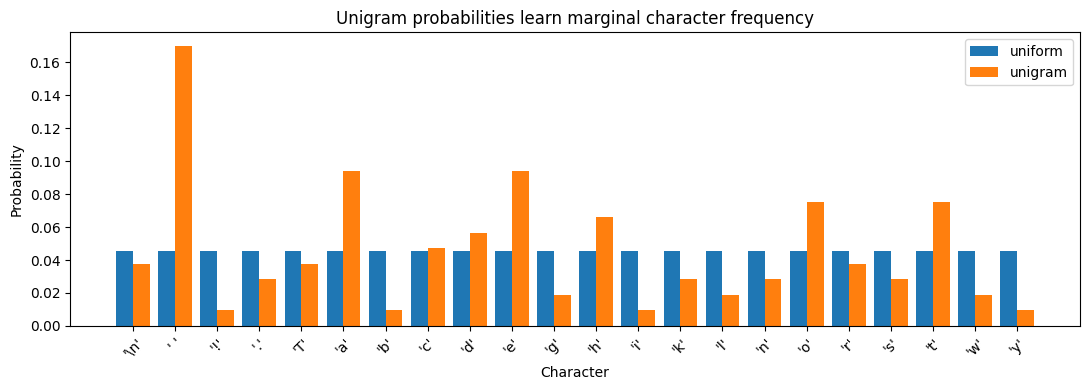

In [10]:
import matplotlib.pyplot as plt  # noqa: I001


x_positions = list(range(len(character_vocabulary)))
bar_width = 0.4

plt.figure(figsize=(11, 4))
plt.bar(
    [position - bar_width / 2 for position in x_positions],
    uniform_probabilities,
    width=bar_width,
    label="uniform",
)
plt.bar(
    [position + bar_width / 2 for position in x_positions],
    unigram_probabilities,
    width=bar_width,
    label="unigram",
)
plt.xlabel("Character")
plt.ylabel("Probability")
plt.title("Unigram probabilities learn marginal character frequency")
plt.xticks(
    x_positions,
    [repr(character) for character in character_vocabulary],
    rotation=45,
)
plt.legend()
plt.tight_layout()
plt.show()

## Compare Average Negative Log Loss

For a sequence of observed target IDs, average negative log loss rewards high probability on the actual targets.

The unigram model was estimated from this same training text, so this comparison measures training fit rather than performance on unseen text.

In [11]:
def average_negative_log_loss(
    target_token_ids: list[int],
    probabilities: list[float],
) -> float:
    if not target_token_ids:
        raise ValueError("At least one target token ID is required.")

    losses = [
        -math.log(probabilities[target_token_id])
        for target_token_id in target_token_ids
    ]
    return sum(losses) / len(losses)


uniform_average_loss = average_negative_log_loss(
    training_token_ids,
    uniform_probabilities,
)
unigram_average_loss = average_negative_log_loss(
    training_token_ids,
    unigram_probabilities,
)

print("Uniform average loss:", uniform_average_loss)
print("Unigram average loss:", unigram_average_loss)
print("Loss improvement:", uniform_average_loss - unigram_average_loss)

assert unigram_average_loss <= uniform_average_loss

Uniform average loss: 3.0910424533583156
Unigram average loss: 2.7979075991061144
Loss improvement: 0.2931348542522012


The unigram loss is lower because the model assigns more probability to characters that occur more often in these targets.

A separate validation text would be needed to assess how well those estimated frequencies generalize.

Losses from different tokenizers or vocabularies should not be compared casually because they define different prediction tasks.

## Give Both Models the Same Interface

Each model maps any input token-ID list to next-token probabilities.

Neither model uses the input values, but they differ in how their fixed distribution is constructed.

In [12]:
class UniformCharacterModel:
    def __init__(self, vocabulary_size: int):
        self._probabilities = build_uniform_probabilities(vocabulary_size)

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        del input_token_ids
        return self._probabilities.copy()


class UnigramCharacterModel:
    def __init__(
        self,
        vocabulary: list[str],
        training_text: str,
    ):
        counts = Counter(training_text)
        self._probabilities = counts_to_probabilities(vocabulary, counts)

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        del input_token_ids
        return self._probabilities.copy()

In [13]:
uniform_model = UniformCharacterModel(len(character_vocabulary))
unigram_model = UnigramCharacterModel(
    character_vocabulary,
    prepared_text,
)

context_a = encode_characters("The ", character_to_id)
context_b = encode_characters("cat", character_to_id)

unigram_after_a = unigram_model.predict_next_token_probabilities(context_a)
unigram_after_b = unigram_model.predict_next_token_probabilities(context_b)

print(
    "Same unigram distribution after both contexts:", unigram_after_a == unigram_after_b
)
assert unigram_after_a == unigram_after_b

Same unigram distribution after both contexts: True


The equality check proves that the unigram model is **context-free**.

It learns which tokens are common but not which tokens follow a particular prompt.

## Sample from Either Model

A shared seeded sampler lets the comparison change only the probability distribution.

In [14]:
import random  # noqa: I001


RANDOM_SEED = 12


def sample_token_id(
    probabilities: list[float],
    random_generator: random.Random,
) -> int:
    validate_probability_distribution(probabilities)
    return random_generator.choices(
        range(len(probabilities)),
        weights=probabilities,
        k=1,
    )[0]

## Generate One Character at a Time

The generator uses the same loop for uniform and unigram models.

Its model parameter accepts either model class because both implement the same prediction method.

In [15]:
def generate_text(
    model: UniformCharacterModel | UnigramCharacterModel,
    prompt: str,
    number_of_new_characters: int,
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
    random_seed: int,
) -> str:
    if number_of_new_characters < 0:
        raise ValueError("number_of_new_characters cannot be negative.")

    random_generator = random.Random(random_seed)
    generated_text = prompt

    for _ in range(number_of_new_characters):
        input_token_ids = encode_characters(generated_text, character_to_id)
        probabilities = model.predict_next_token_probabilities(input_token_ids)
        next_token_id = sample_token_id(probabilities, random_generator)
        generated_text += id_to_character[next_token_id]

    return generated_text

In [16]:
uniform_generated_text = generate_text(
    uniform_model,
    "The ",
    120,
    character_to_id,
    id_to_character,
    RANDOM_SEED,
)
unigram_generated_text = generate_text(
    unigram_model,
    "The ",
    120,
    character_to_id,
    id_to_character,
    RANDOM_SEED,
)

print("Uniform generation:")
print(uniform_generated_text)
print()
print("Unigram generation:")
print(unigram_generated_text)

Uniform generation:
The gll.
dbrnkil.e.t s ncds
 wh!yw!e!bk.n .rdekgd
nyylccnl!achrh
sehTedo!i.n
bcl gTbgygy.wdTow
aoca

kyyh
crslahgkawt.btbwhn

Unigram generation:
The dhh 
aTokgeh d t o kacr
 te wt c ah k  occgdb
ltwhaaki .aeoe
oce.cco e k
Tah d!Tdtdt ta nt
Toa.
 hwye
aorh.edhTts asTtek


The unigram sample tends to contain corpus-common characters more often.

That does not guarantee recognizable words because independent draws still ignore local order.

A single random sample is illustrative rather than a reliable evaluation by itself.

## Prove That the Prompt Is Still Ignored

With the same seed, two prompts receive identical sampled suffixes because the unigram distribution never changes.

In [17]:
cat_generation = generate_text(
    unigram_model,
    "The cat ",
    70,
    character_to_id,
    id_to_character,
    RANDOM_SEED,
)
dog_generation = generate_text(
    unigram_model,
    "The dog ",
    70,
    character_to_id,
    id_to_character,
    RANDOM_SEED,
)

cat_suffix = cat_generation[len("The cat ") :]
dog_suffix = dog_generation[len("The dog ") :]

print("Cat result:", repr(cat_generation))
print("Dog result:", repr(dog_generation))
print("Suffixes match:", cat_suffix == dog_suffix)

assert cat_suffix == dog_suffix

Cat result: 'The cat dhh \naTokgeh d t o kacr\n te wt c ah k  occgdb\nltwhaaki .aeoe\noce.cco e'
Dog result: 'The dog dhh \naTokgeh d t o kacr\n te wt c ah k  occgdb\nltwhaaki .aeoe\noce.cco e'
Suffixes match: True


## Verify Long-Run Sampling Frequencies

Over many independent draws, sampled frequencies should approach the unigram probabilities.

Finite samples retain random variation.

In [18]:
random_generator = random.Random(RANDOM_SEED)
sample_size = 10_000
sampled_ids = [
    sample_token_id(unigram_probabilities, random_generator) for _ in range(sample_size)
]
sampled_counts = dict.fromkeys(character_vocabulary, 0)

for token_id in sampled_ids:
    sampled_counts[id_to_character[token_id]] += 1

sampled_frequencies = [
    sampled_counts[character] / sample_size for character in character_vocabulary
]
maximum_absolute_error = max(
    abs(expected - observed)
    for expected, observed in zip(
        unigram_probabilities,
        sampled_frequencies,
        strict=True,
    )
)

print("Sample size:", sample_size)
print("Maximum absolute frequency error:", maximum_absolute_error)

Sample size: 10000
Maximum absolute frequency error: 0.0034603773584905573


The small maximum error confirms that the sampler follows the learned distribution.

It verifies implementation behavior rather than language quality.

## Show the Same Prediction After Every Context

The most probable next character is whichever character is most frequent overall.

That answer remains unchanged after `T`, `Th`, a space, or a period.

In [19]:
for context in ["T", "Th", "The ", "The cat", "."]:
    context_ids = encode_characters(context, character_to_id)
    probabilities = unigram_model.predict_next_token_probabilities(context_ids)
    most_likely_id = max(
        range(len(probabilities)),
        key=probabilities.__getitem__,
    )
    print(
        f"context={context!r:<10} "
        f"prediction={id_to_character[most_likely_id]!r} "
        f"probability={probabilities[most_likely_id]:.6f}"
    )

context='T'        prediction=' ' probability=0.169811
context='Th'       prediction=' ' probability=0.169811
context='The '     prediction=' ' probability=0.169811
context='The cat'  prediction=' ' probability=0.169811
context='.'        prediction=' ' probability=0.169811


After `Th`, a useful contextual model should favor `e` in this corpus.

The unigram model cannot express that dependency because it never conditions on the previous token.

## What the Model Learned

The unigram model learned:

- one count for each vocabulary character;
- one marginal probability for each character; and
- a lower training loss than the uniform baseline.

It did not learn:

- token order;
- spelling;
- punctuation placement;
- word boundaries; or
- prompt-specific continuation.

## Takeaways

- A unigram model predicts from overall token frequency and ignores context.
- Dividing each count by the total count produces empirical probabilities.
- The probability list must follow the same order as token IDs.
- The unigram model matches corpus marginal frequencies rather than assigning a flat distribution.
- On these training targets, its average negative log loss is lower than the uniform baseline.
- Seeded generation reflects common-character frequency but still lacks coherent order.
- Identical suffixes after different prompts prove that the model is context-free.
- Long-run sampled frequencies approach the learned unigram probabilities.

The next chapter will build a bigram model whose next-token distribution depends on the immediately previous token.